In [2]:

import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import minimize
from iminuit.cost import LeastSquares

from iminuit import Minuit

sns.set_context("paper", font_scale=1.4)
sns.set_style("ticks")


## asked chat to make a polar inspirede colormap
pallete = [
    "#234F5C",  # deep fjord teal (dark)
    "#F2A47D",  # arctic sunset orange
    "#9975B1",  # low sun gold
    "#98FDEE",  # electric ice cyan
        "#8DF596",  # frozen horizon red

    "#1F7A8C",  # glacial lagoon
    "#FF4E88",  # polar pink sky
    "#2E294E",  # polar night indigo
    "#541388",  # aurora violet
    "#3A5A40",  # tundra moss
    "#A1E3F9",  # fractured ice blue
    "#8E44AD",  # deep aurora magenta
    "#00B3A4",  # icy turquoise
]

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", pallete)

plt.rcParams['figure.figsize'] = (16, 9)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.facecolor'] =     "#DDDCDC"  # frozen mist (very light)
## color of legend frame
plt.rcParams["legend.facecolor"] = "#FFFFFF"
plt.rcParams["legend.edgecolor"] = "#010003"
plt.rcParams["legend.framealpha"] = .9

rc = {"font.family" : "serif", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
mpl_markers = ['o', 'v', 's', 'p', '*', 'P', 'd']

(array([2824., 1917., 1609., 1593., 1639., 1787., 1970., 2189., 2325.,
        2147.]),
 array([-1.0000e+00, -8.0001e-01, -6.0002e-01, -4.0003e-01, -2.0004e-01,
        -5.0000e-05,  1.9994e-01,  3.9993e-01,  5.9992e-01,  7.9991e-01,
         9.9990e-01]),
 <BarContainer object of 10 artists>)

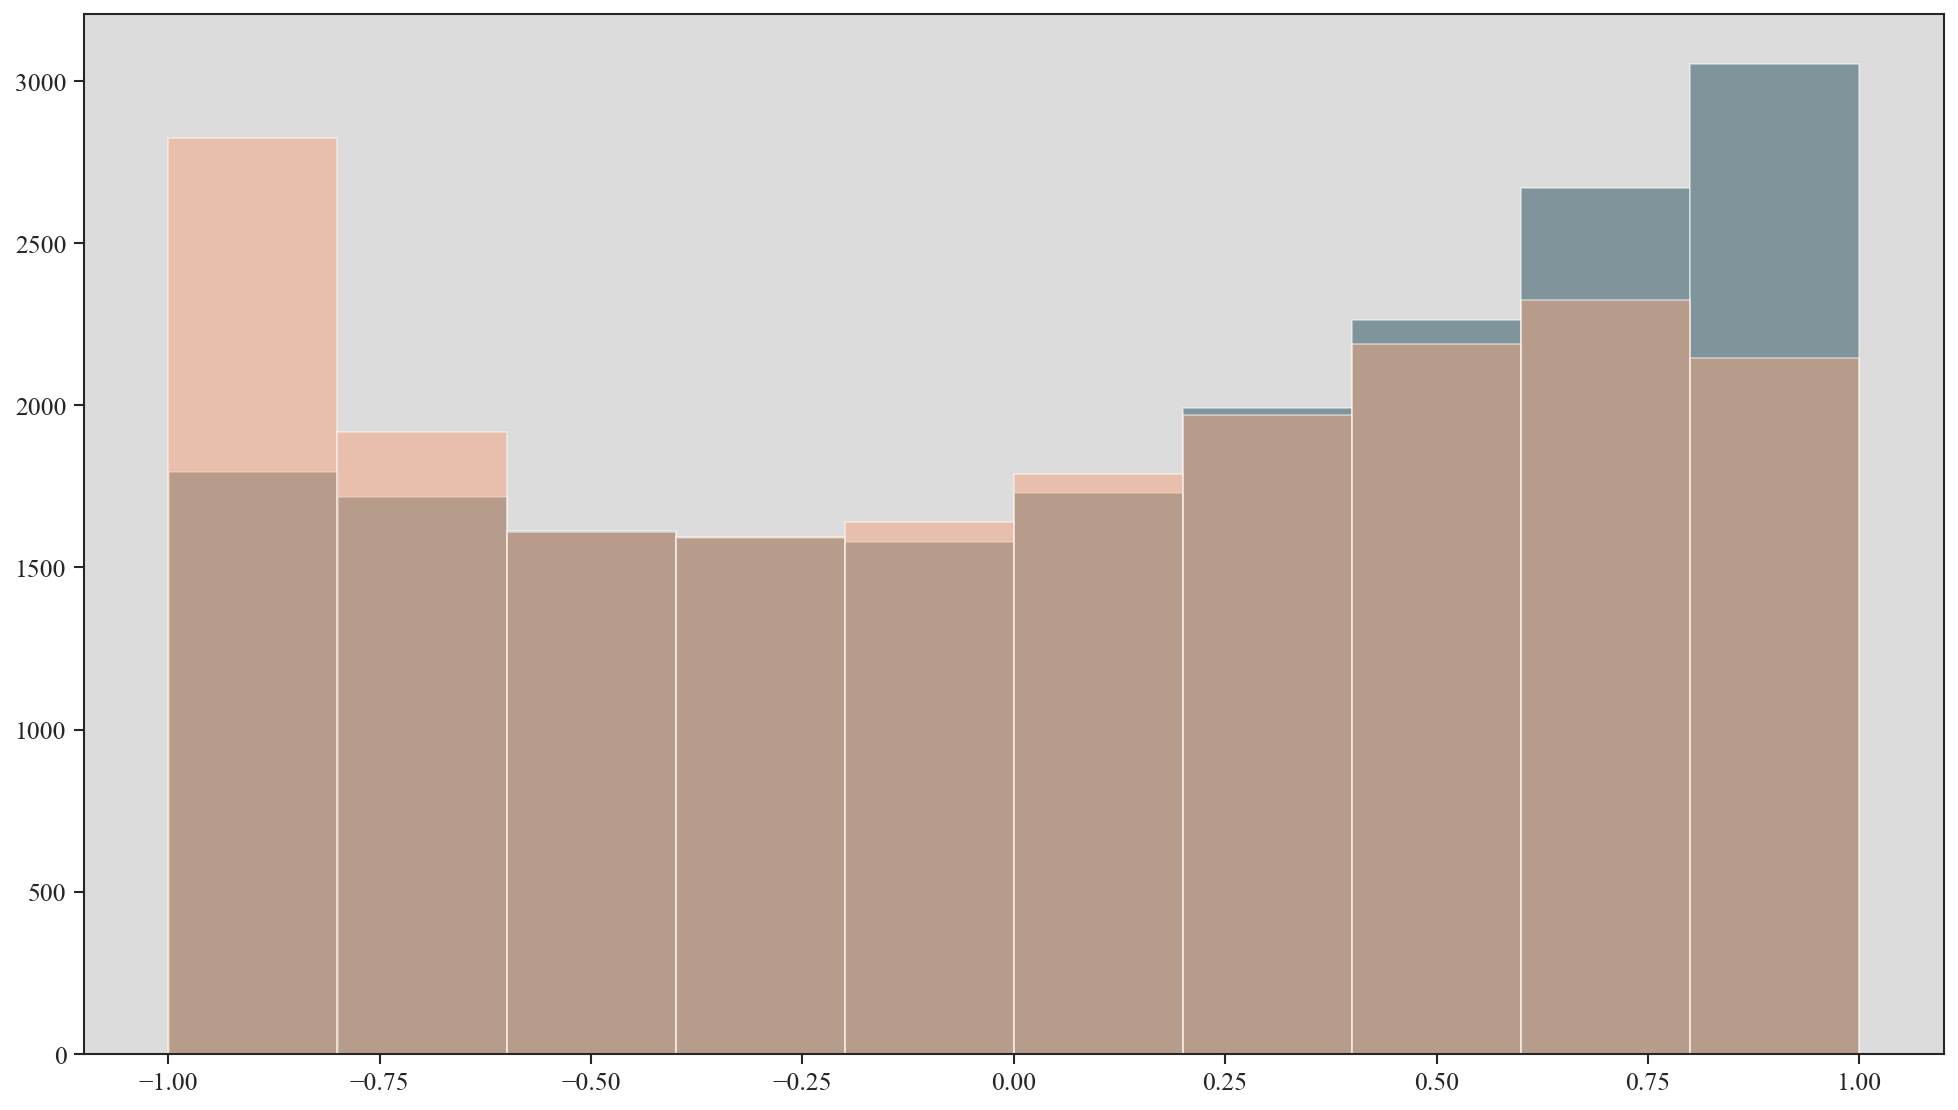

In [3]:
dat = np.genfromtxt('/Users/jeppegrejspetersen/Code/AMAS(APPSTAT2)/week3/MLE_Variance_data_2.txt')
plt.hist(dat[:,0], alpha = 0.5)
plt.hist(dat[:,1], alpha = 0.5)

In [4]:
def pdf_f(x,a,b):
    return 1 / (2/3 * b *(0.95**3) + 2*0.95) * (1 + a * x + b * x**2)

def negative_ln_likelihood(x,a,b):
    return - np.log(pdf_f(x,a,b))

def negative_ln_likelihood_dat(params, data):
    return np.sum(- np.log(pdf_f(data,*params)))

results0= minimize(negative_ln_likelihood_dat, x0 = [0.5,0.5], args = (dat[:,0]))
cov0 = results0.hess_inv
errors0 = np.sqrt(np.diag(cov0))
print("Best fit parameters:", results0.x)

results1= minimize(negative_ln_likelihood_dat, x0 = [0.5,0.5], args = (dat[:,1]))
cov1 = results1.hess_inv
errors1 = np.sqrt(np.diag(cov1))
print("Best fit parameters:", results1.x)


Best fit parameters: [0.50503347 1.20919505]
Best fit parameters: [0.079687   1.23527176]


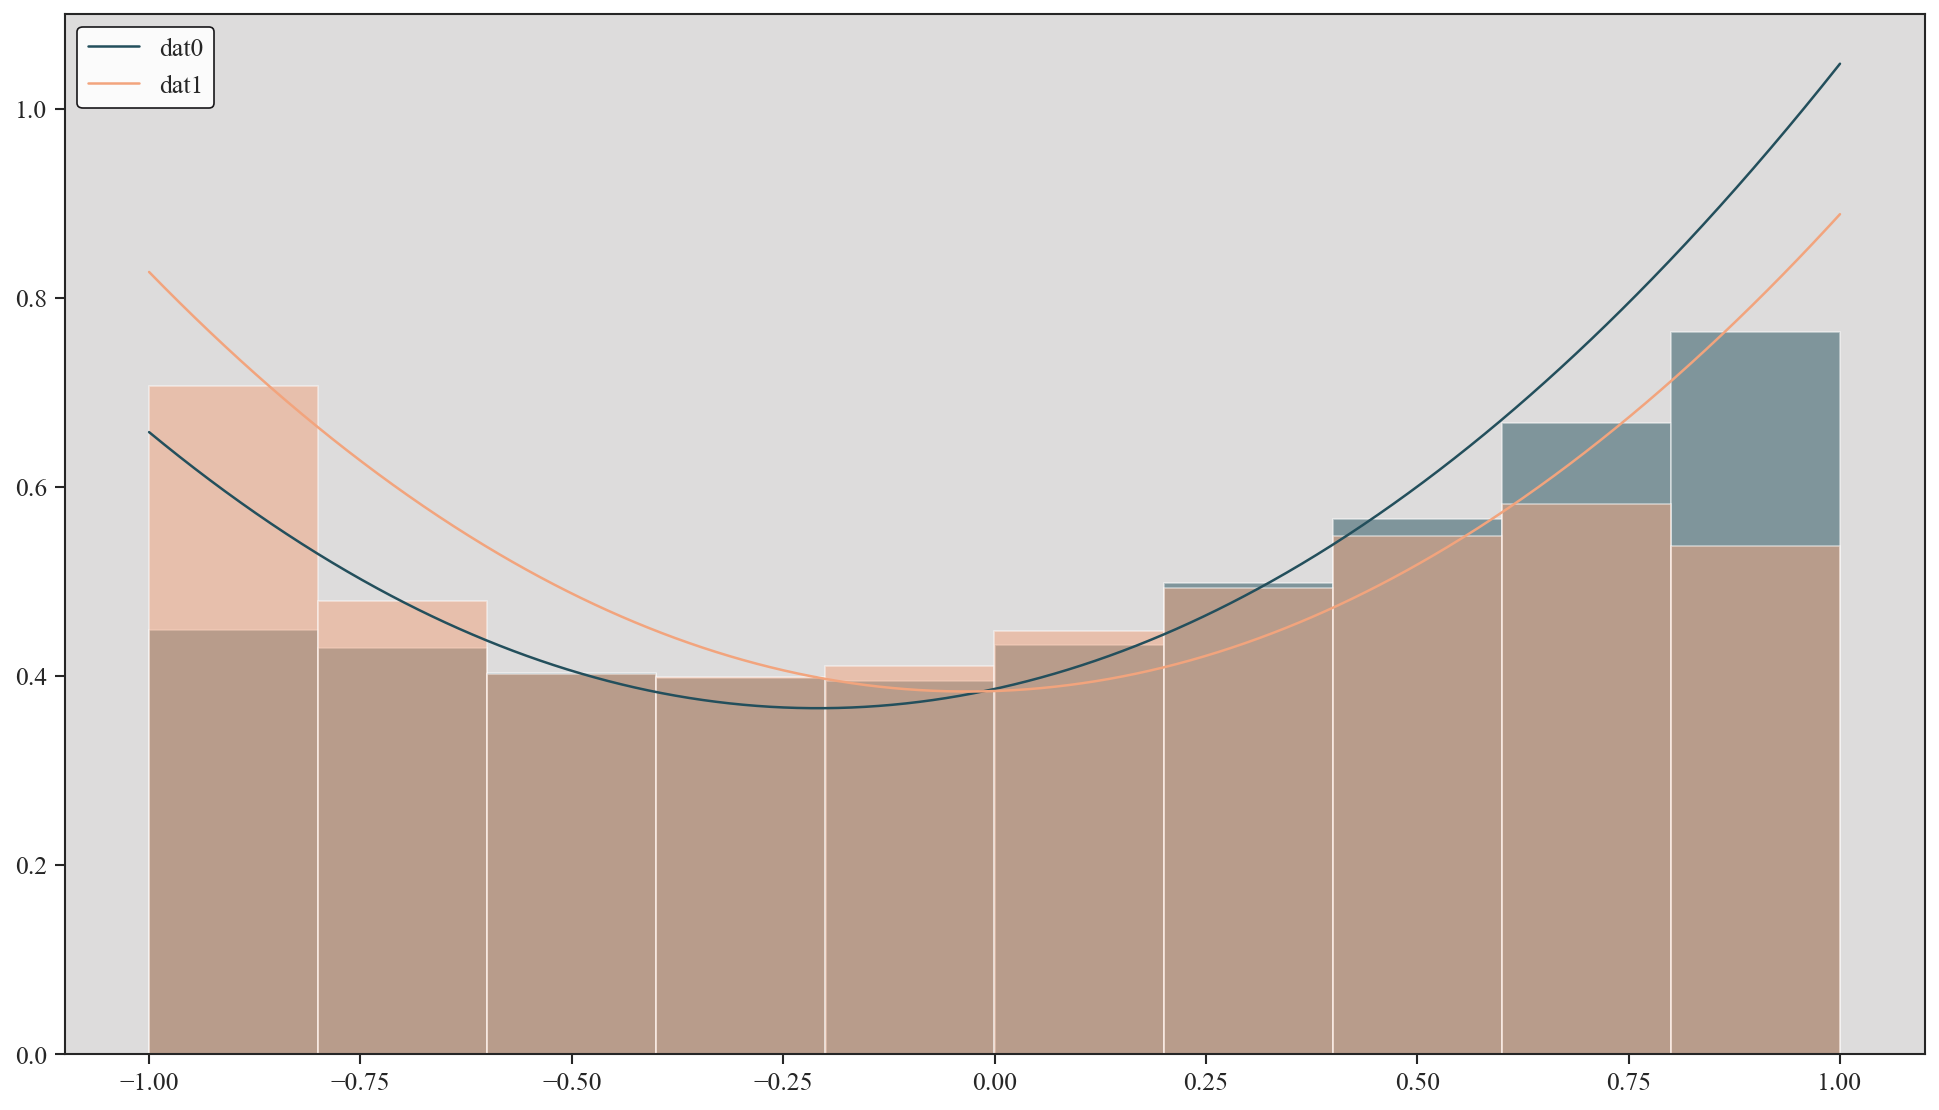

In [5]:
x_plot = np.linspace(-1,1,1000)
plt.hist(dat[:,0], alpha = 0.5, density= True, color= pallete[0])
plt.plot(x_plot, pdf_f(x_plot,*results0.x), label = 'dat0', color = pallete[0])
plt.hist(dat[:,1], alpha = 0.5, density= True, color= pallete [1])
plt.plot(x_plot, pdf_f(x_plot, *results1.x), label = 'dat1', color = pallete[1])
plt.legend()

In [6]:
def get_ranges(contour_obj):
    x_all = []
    y_all = []
    for path in contour_obj.get_paths():
        vertices = path.vertices
        x_all.extend(vertices[:,0])
        y_all.extend(vertices[:,1])
    x_all = np.array(x_all)
    y_all = np.array(y_all)
    return np.min(x_all), np.max(x_all), np.min(y_all), np.max(y_all)

In [7]:
## dataset 0
alph_range = np.linspace(.3,.7, 500)
bet_range = np.linspace(.8,1.5, 500)
like = np.empty((500,500))
for i in range(500):
        for j in range(500):
            like[i,j] = negative_ln_likelihood_dat((alph_range[i], bet_range[j]), dat[:,0])
A,B = np.meshgrid(alph_range, bet_range)


alpha: 0.5052104208416833 +- 0.0302718921825606
beta: 1.209619238476954 +- 0.07219287042261358


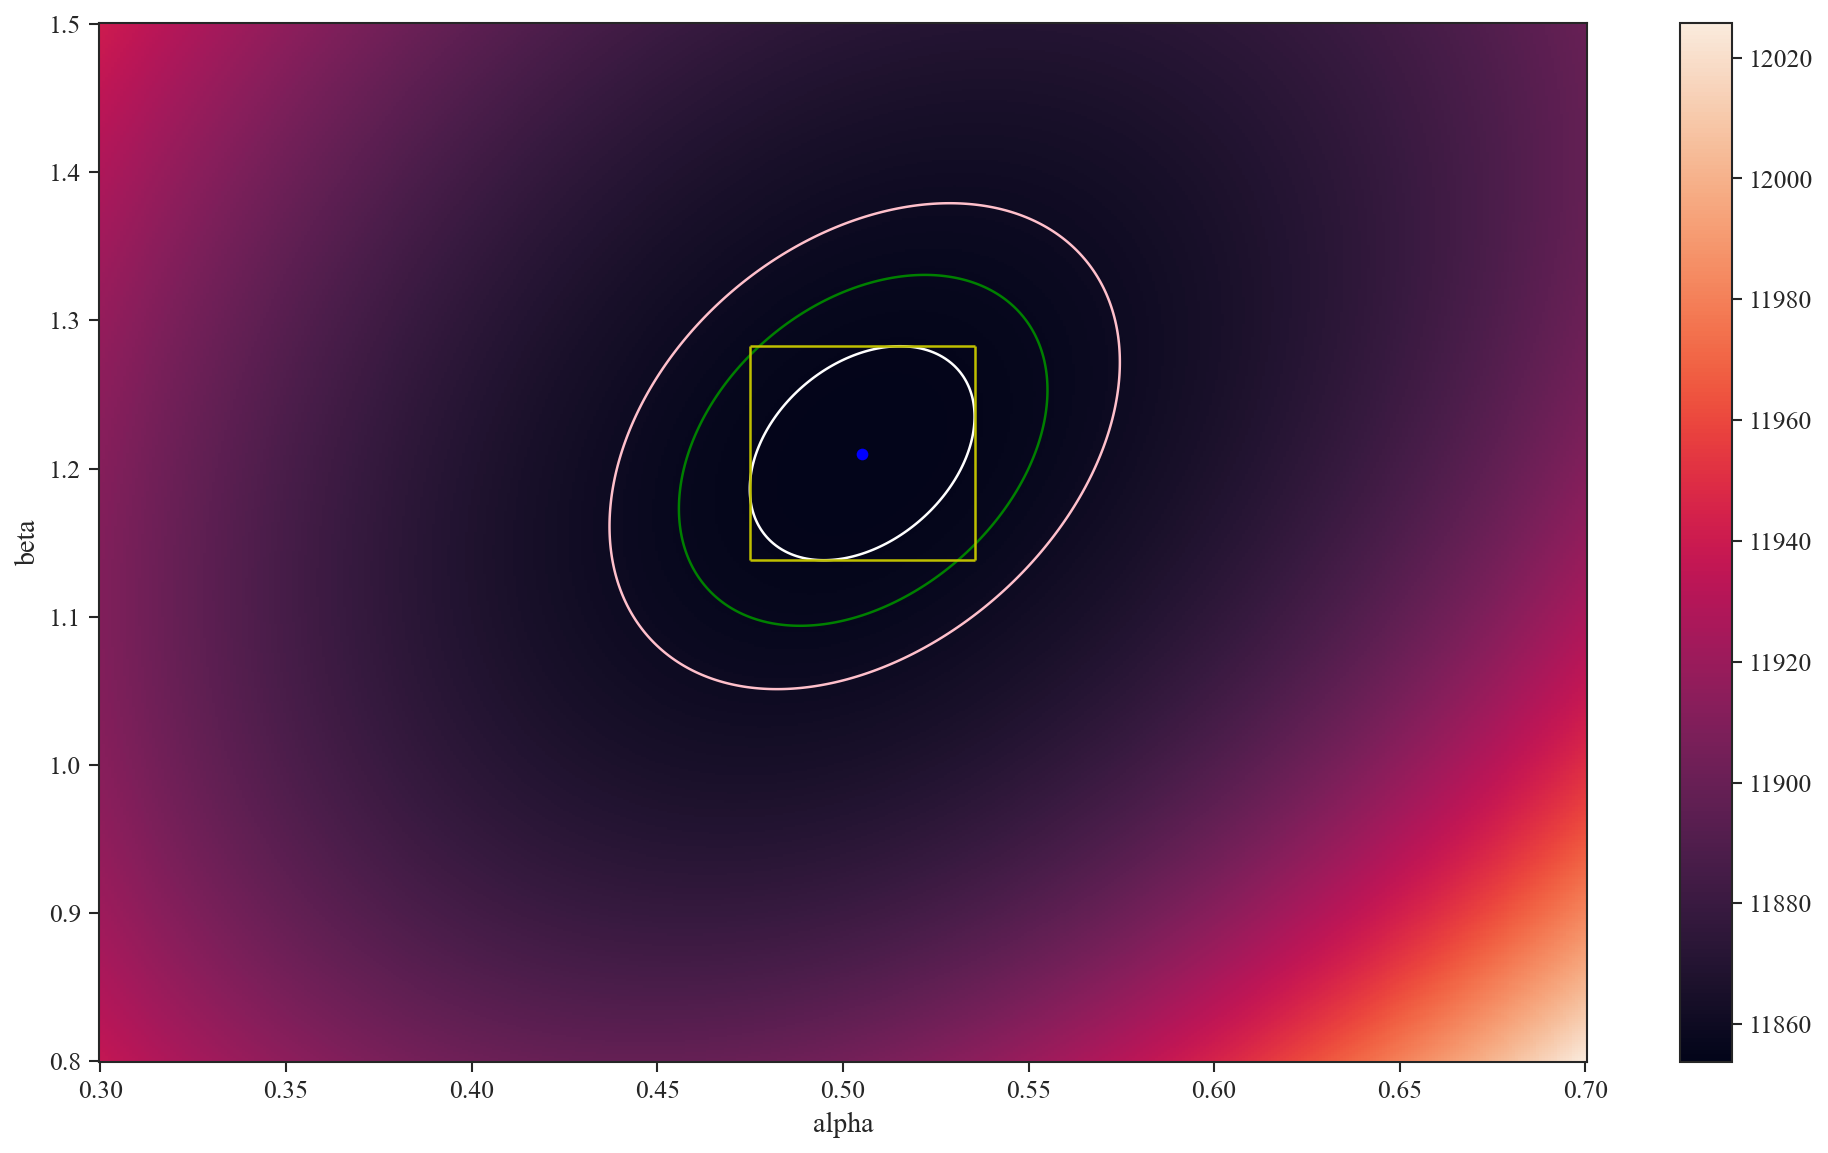

In [8]:
plt.pcolormesh(A,B, like.T)
plt.xlabel("alpha")
plt.ylabel("beta")
plt.colorbar()

min_like = np.min(like)
argmin = np.unravel_index(np.argmin(like), like.shape)
plt.scatter(alph_range[argmin[0]], bet_range[argmin[1]], color = "blue", label = "ML estimate")
like_new = like - min_like
c1 = plt.contour(A, B, like_new.T, levels=[1.15], colors="white", )
plt.contour(A, B, like_new.T, levels=[3.09], colors="green", )
plt.contour(A, B, like_new.T, levels=[5.92], colors="pink", )
xmin, xmax, ymin, ymax = get_ranges(c1)
plt.vlines(xmax, ymin, ymax, colors='y')
plt.vlines(xmin, ymin, ymax, colors='y')
plt.hlines(ymin, xmin, xmax, colors='y')
plt.hlines(ymax, xmin, xmax, colors='y')
sig_a = (xmax - xmin) / 2
sig_b = (ymax - ymin) / 2
print("alpha:", alph_range[argmin[0]], "+-", sig_a)
print("beta:", bet_range[argmin[1]], "+-", sig_b)

In [9]:
## dataset 1
alph_range = np.linspace(0,.25, 500)
bet_range = np.linspace(1.1,1.5, 500)
like = np.empty((500,500))
for i in range(500):
        for j in range(500):
            like[i,j] = negative_ln_likelihood_dat((alph_range[i], bet_range[j]), dat[:,1])
A,B = np.meshgrid(alph_range, bet_range)


alpha: 0.07965931863727455 +- 0.02964693529713826
beta: 1.2354709418837675 +- 0.07301944042229391


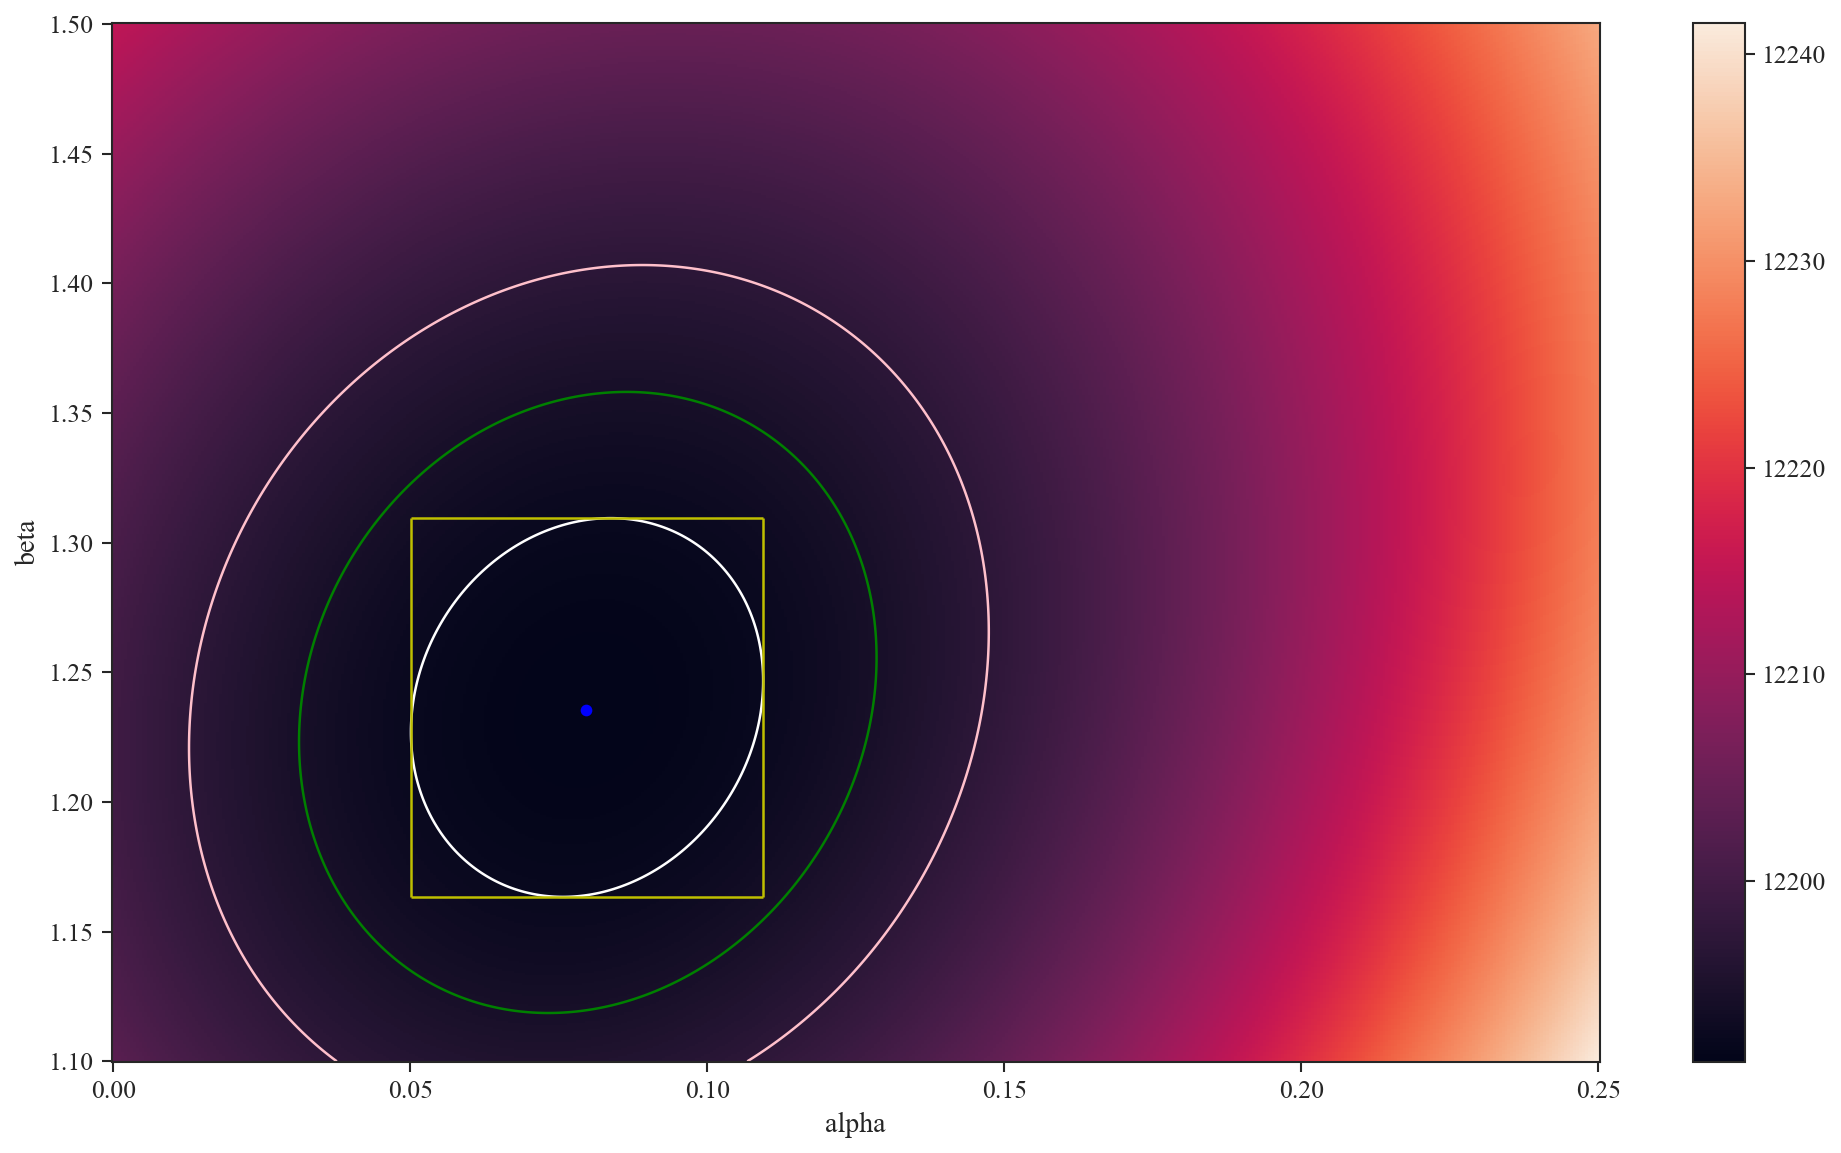

In [10]:
plt.pcolormesh(A,B, like.T)
plt.xlabel("alpha")
plt.ylabel("beta")
plt.colorbar()

min_like = np.min(like)
argmin = np.unravel_index(np.argmin(like), like.shape)
plt.scatter(alph_range[argmin[0]], bet_range[argmin[1]], color = "blue", label = "ML estimate")
like_new = like - min_like
c1 = plt.contour(A, B, like_new.T, levels=[1.15], colors="white", )
plt.contour(A, B, like_new.T, levels=[3.09], colors="green", )
plt.contour(A, B, like_new.T, levels=[5.92], colors="pink", )
xmin, xmax, ymin, ymax = get_ranges(c1)
plt.vlines(xmax, ymin, ymax, colors='y')
plt.vlines(xmin, ymin, ymax, colors='y')
plt.hlines(ymin, xmin, xmax, colors='y')
plt.hlines(ymax, xmin, xmax, colors='y')
sig_a = (xmax - xmin) / 2
sig_b = (ymax - ymin) / 2
print("alpha:", alph_range[argmin[0]], "+-", sig_a)
print("beta:", bet_range[argmin[1]], "+-", sig_b)


______
## unbinned, testing binned

In [15]:
def pdf_f(x,a,b,N):
    return (1 / (2/3 * b *(0.95**3) + 2*0.95) * (1 + a * x + b * x**2))/N

<ErrorbarContainer object of 3 artists>

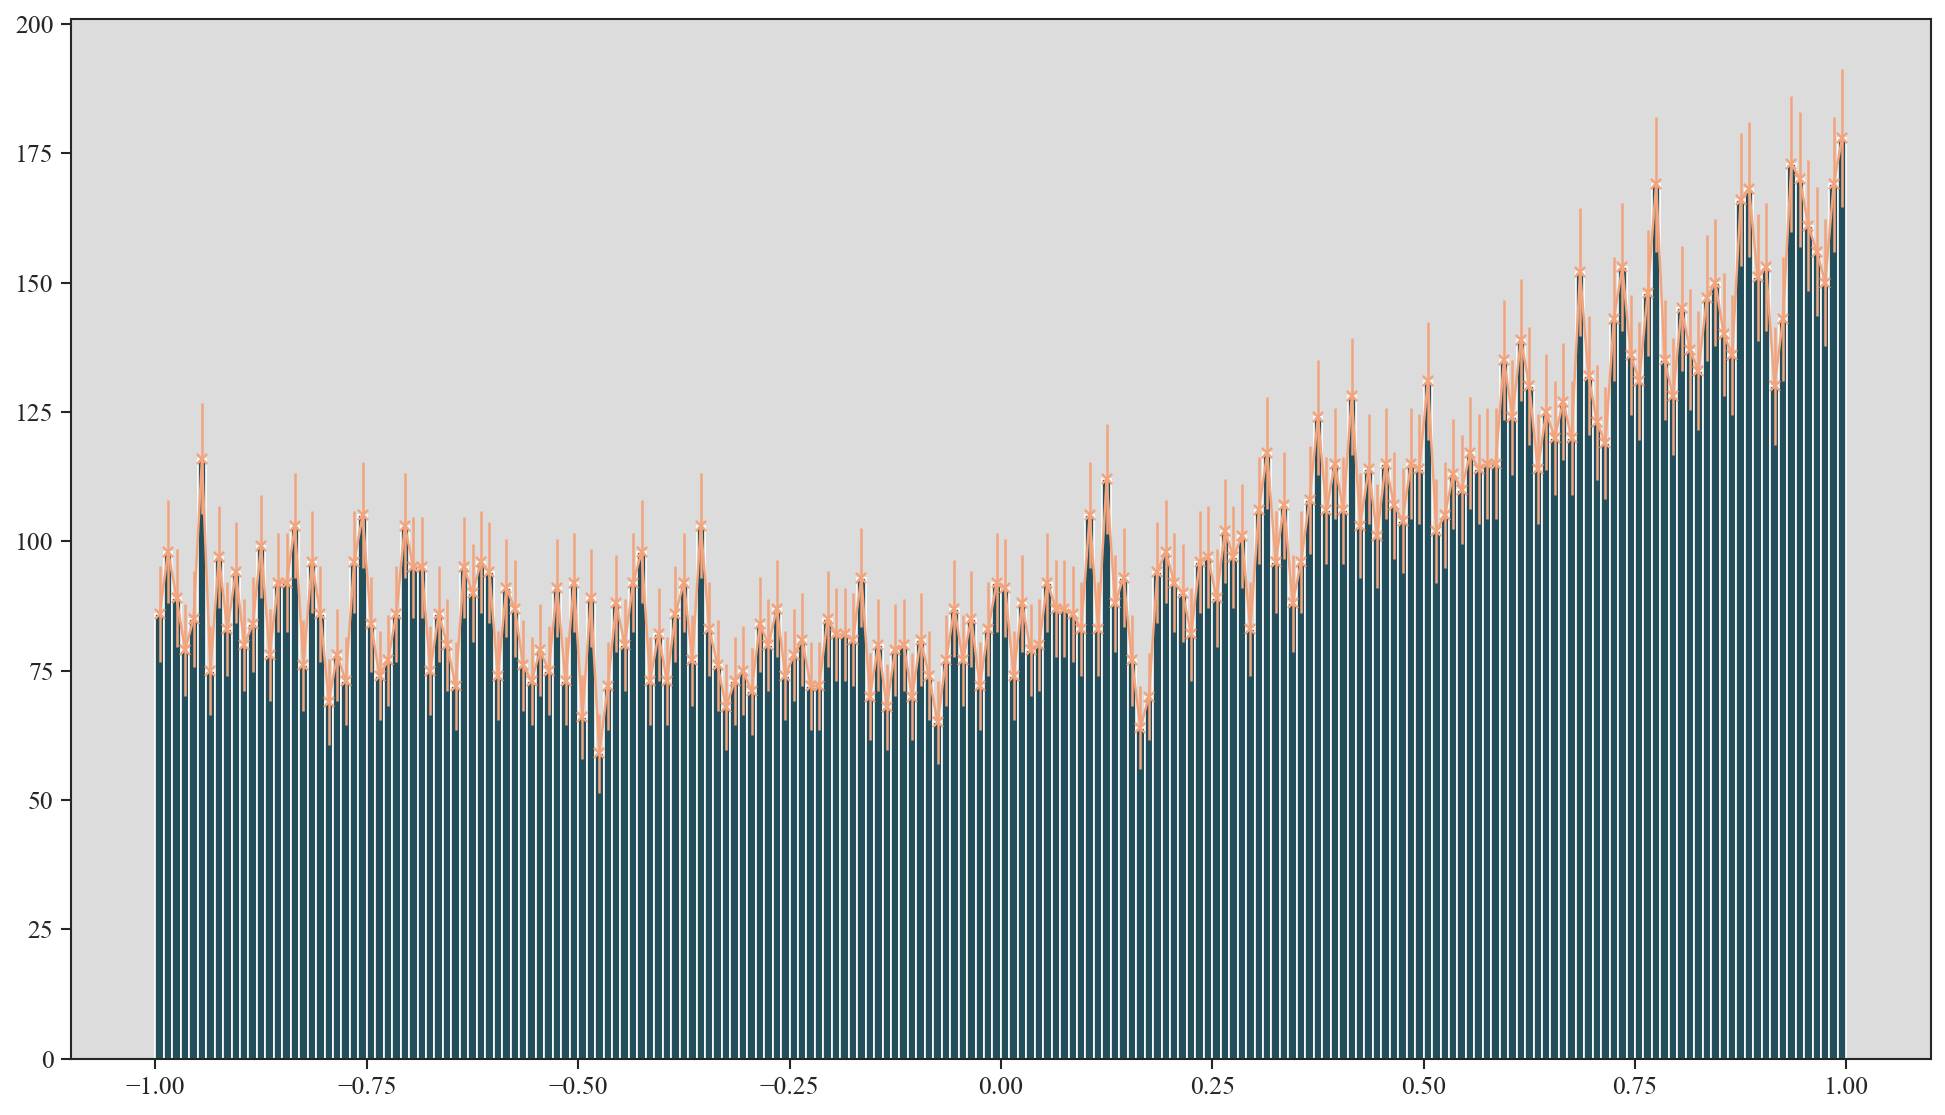

In [37]:
N_bins = 200
bins = np.linspace(-1,1,N_bins+1)
bin_centers = (bins[:-1] + bins[1:]) / 2
counts0 = plt.hist(dat[:,0], bins=bins, density = False)
plt.plot(bin_centers, counts0[0], '-x', color = pallete[1], label = "dat0")
plt.errorbar(bin_centers, counts0[0], yerr = np.sqrt(counts0[0]), fmt = 'x', color = pallete[1])

In [38]:
least_squares = LeastSquares(bin_centers, counts0[0], np.sqrt(counts0[0])  , pdf_f)
m = Minuit(least_squares, a=1.0, b=0.0, N = 250)  # initial guesses
m.migrad()   # minimize
print(scipy.stats.chi2.cdf(m.fval,df =len(bin_centers)-3))
m.migrad()

0.7695138045764524


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 211.3 (χ²/ndof = 1.1)      │              Nfcn = 169              │
│ EDM = 2.82e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.413   │   0.016   │            │            │         │         │       │
│ 1 │ b    │   0.558   │   0.034   │            │            │         │         │       │
│ 2 │ N    │  5.40e-3  │  0.04e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬────────────────────────────┐
│   │        a        b        N │
├───┼────────────────────────────┤
│ a │ 0.000261  0.20e-3  25.7e-9 │
│ b │  0.20e-3  0.00114 145.1e-9 │
│ N │  25.7e-9 145.1e-9 1.49e-09 │
└───┴────────────────────────────┘

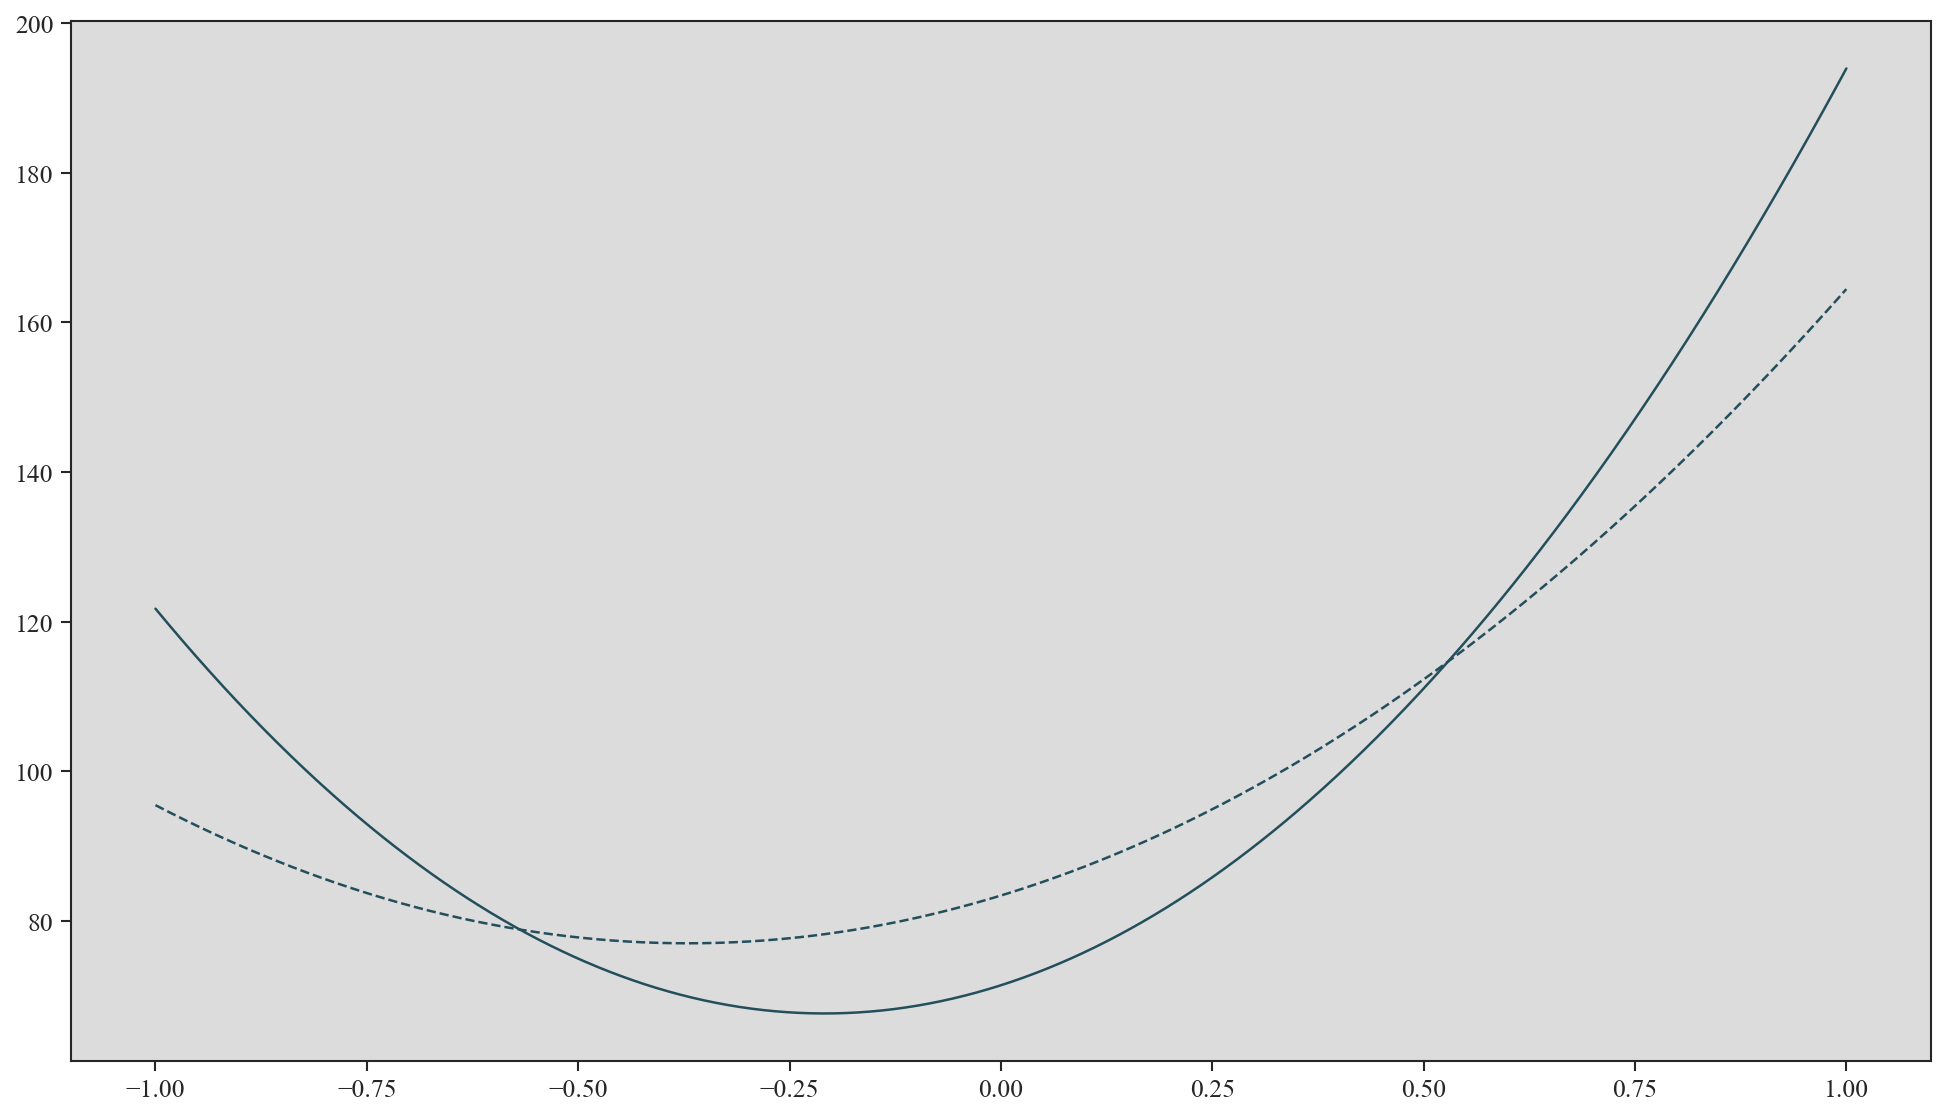

In [39]:
alpha = 0.5052104208416833 
beta = 1.209619238476954 
plt.plot(x_plot, pdf_f(x_plot, alpha, beta,m.values["N"]), label = 'fit', color = pallete[0])
plt.plot(x_plot, pdf_f(x_plot, 
                       m.values["a"], 
                       m.values["b"], 
                       m.values["N"]),
         label='fit from MLE',
         linestyle="--")